## TESLA STOCK PRICE PREDICTION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error


In [2]:
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv("TSLA.csv")

# Basic info
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (2416, 7)

First 5 rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [4]:
print(" DATASET INFO ")
print(df.info())

print("\n BASIC STATISTICS ")
print(df.describe())

print("\n MISSING VALUES ")
print(df.isnull().sum())

 DATASET INFO 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.2+ KB
None

 BASIC STATISTICS 
              Open         High          Low        Close    Adj Close  \
count  2416.000000  2416.000000  2416.000000  2416.000000  2416.000000   
mean    186.271147   189.578224   182.916639   186.403651   186.403651   
std     118.740163   120.892329   116.857591   119.136020   119.136020   
min      16.139999    16.629999    14.980000    15.800000    15.800000   
25%      34.342498    34.897501    33.587501    34.400002   

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.set_index('Date')

print("Date range:", df.index.min(), "to", df.index.max())
print("Total trading days:", len(df))
df.head()

Date range: 2010-06-29 00:00:00 to 2020-02-03 00:00:00
Total trading days: 2416


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


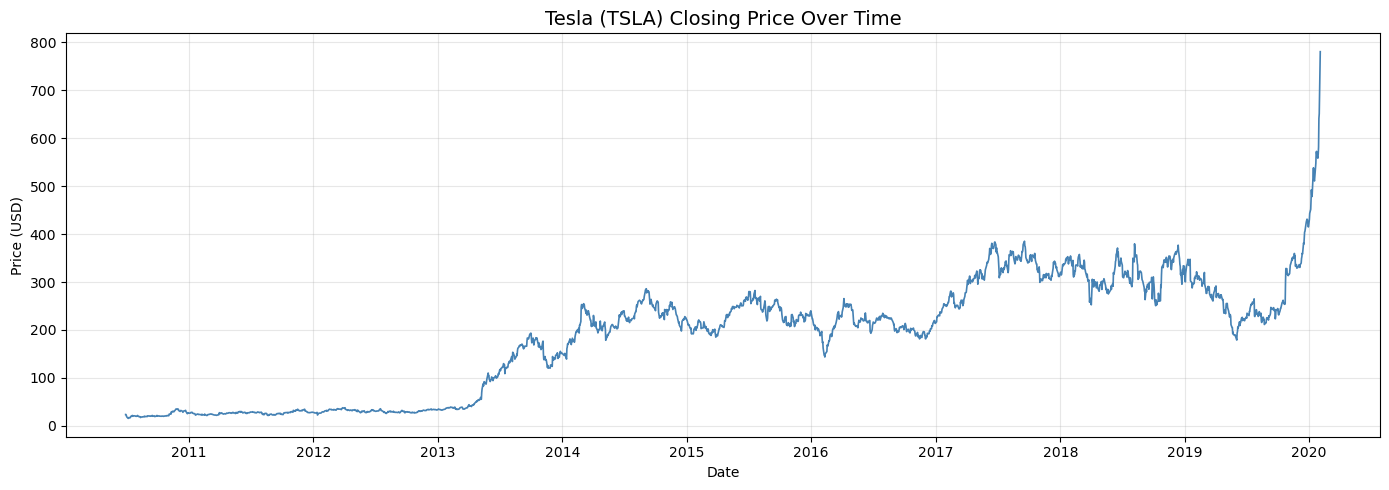

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df['Close'], color='steelblue', linewidth=1.2)
plt.title('Tesla (TSLA) Closing Price Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

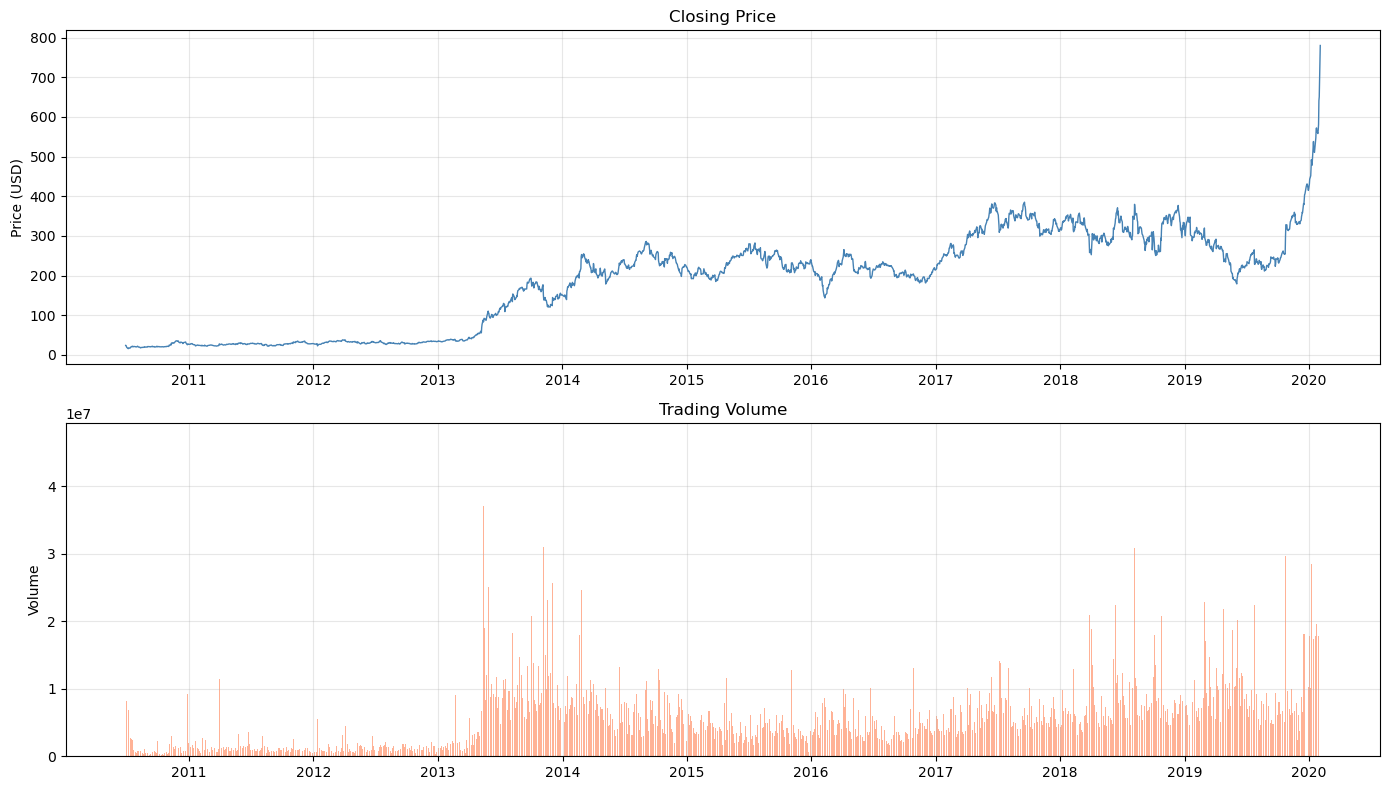

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Closing price
axes[0].plot(df['Close'], color='steelblue', linewidth=1)
axes[0].set_title('Closing Price')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(alpha=0.3)

# Volume
axes[1].bar(df.index, df['Volume'], color='coral', alpha=0.6, width=1)
axes[1].set_title('Trading Volume')
axes[1].set_ylabel('Volume')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

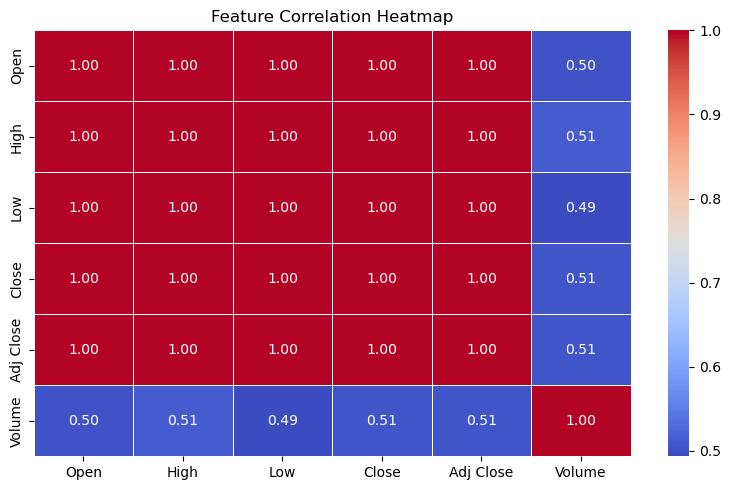

In [8]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [9]:
# Data Cleaning

print("MISSING VALUES BEFORE")
print(df.isnull().sum())

df = df.fillna(method="ffill")

df = df.fillna(method='bfill')

print("\n MISSING VALUES AFTER ")
print(df.isnull().sum())

MISSING VALUES BEFORE
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

 MISSING VALUES AFTER 
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [10]:
## Duplicate Check

print("Duplicate rows:", df.duplicated().sum())

df= df.drop_duplicates()
print("Shape after cleaning:", df.shape)

Duplicate rows: 0
Shape after cleaning: (2416, 6)


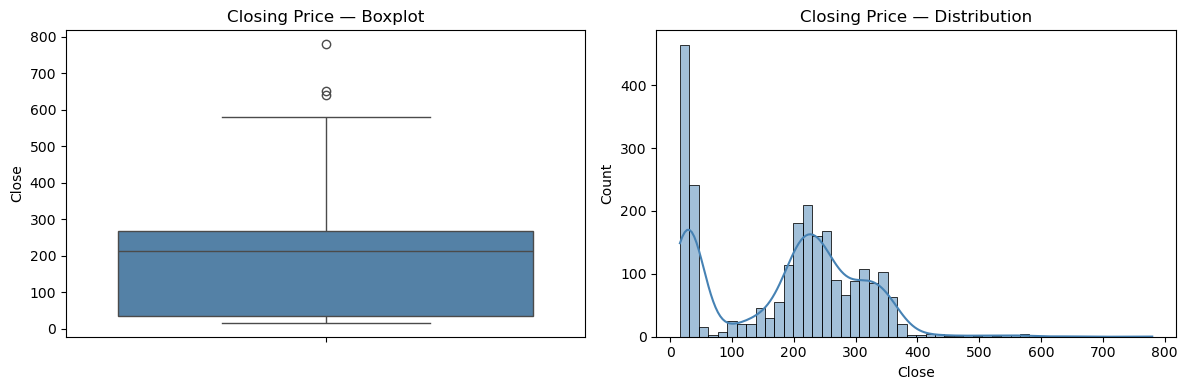

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Close'], color='steelblue')
plt.title('Closing Price — Boxplot')

plt.subplot(1, 2, 2)
sns.histplot(df['Close'], bins=50, color='steelblue', kde=True)
plt.title('Closing Price — Distribution')

plt.tight_layout()
plt.show()

In [12]:
print(" FINAL CLEAN DATA ")
print("Shape:", df.shape)
print("Data range:", df.index.min(), "to", df.index.max())
print("Any nulls left:", df.isnull().sum().sum())
df.head()

 FINAL CLEAN DATA 
Shape: (2416, 6)
Data range: 2010-06-29 00:00:00 to 2020-02-03 00:00:00
Any nulls left: 0


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


## Data Preprocessing

In [13]:
data = df[['Adj Close']].copy()

# MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

print("Orginal price range:", data['Adj Close'].min(), "to", data['Adj Close'].max())
print("Scaled range:", scaled_data.min(), "to", scaled_data.max())

Orginal price range: 15.8 to 780.0
Scaled range: 0.0 to 1.0


In [14]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])  # age er 60 din
        y.append(data[i, 0])                # next din er price
    return np.array(X), np.array(y)

WINDOW_SIZE = 60  # age er 60 din dekhe predict korbe

X, y = create_sequences(scaled_data, WINDOW_SIZE)
print("X shape:", X.shape)  # (samples, 60)
print("y shape:", y.shape)  # (samples,)

X shape: (2356, 60)
y shape: (2356,)


In [15]:
## Train/Test split

split = int(len(X) * 0.80)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1884, 60)
Test size: (472, 60)


In [16]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train reshaped:", X_train.shape)
print("X_test reshaped:", X_test.shape)

X_train reshaped: (1884, 60, 1)
X_test reshaped: (472, 60, 1)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

rnn_model = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(60, 1)),
    Dropout(0.2),
    SimpleRNN(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mean_squared_error')
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 60, 64)              │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_rnn_model.h5', save_best_only=True)
]

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
51/53 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0558

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0310 - val_loss: 0.0027
Epoch 2/50
51/53 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0075

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0062 - val_loss: 0.0013
Epoch 3/50
51/53 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0044

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0041 - val_loss: 3.7118e-04
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0032 - val_loss: 4.9083e-04
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0024 - val_loss: 0.0010
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0020 - val_loss: 5.3521e-04
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0016 - val_loss: 7.4493e-04
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0015 - val_loss: 6.2362e-04


In [19]:
# LSTM MODEL

import tensorflow as tf
tf.keras.backend.clear_session()

lstm_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(60, 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_lstm_model.keras', save_best_only=True)
]

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks_lstm,
    verbose=1
)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0064 - val_loss: 6.4205e-04
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 7.7017e-04 - val_loss: 6.3923e-04
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 7.1224e-04 - val_loss: 4.7733e-04
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 6.7722e-04 - val_loss: 4.5637e-04
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 6.1581e-04 - val_loss: 7.9155e-04
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 6.4795e-04 - val_loss: 4.4977e-04
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 6.0263e-04 - val_loss: 4.5064e-04
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4.9530e-04 - val_loss: 4.1657e-04
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4.6322e-04 - val_loss: 7.8560e-04
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.2505e-04 - val_loss: 4.7104e-04
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4.7582e-04 - 

In [21]:
# Prediction
rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)

# Inverse transform
rnn_pred_actual = scaler.inverse_transform(rnn_pred)
lstm_pred_actual =  scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Prediction done!")
print("Sample RNN prediction:", rnn_pred_actual[:3].flatten())
print("Sample LSTM predictions:", lstm_pred_actual[:3].flatten())
print("Actual values:", y_test_actual[:3].flatten())


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Prediction done!
Sample RNN prediction: [332.88684 308.75943 311.00412]
Sample LSTM predictions: [327.17886 324.2656  321.49765]
Actual values: [310.549988 316.529999 309.100006]


In [22]:
## MSE & RMSE calculate

from sklearn.metrics import mean_squared_error
import numpy as np

rnn_mse = mean_squared_error(y_test_actual, rnn_pred_actual)
lstm_mse = mean_squared_error(y_test_actual, lstm_pred_actual)

rnn_rmse = np.sqrt(rnn_mse)
lstm_rmse = np.sqrt(lstm_mse)

print("=== MODEL PERFORMANCE ===")
print(f"SimpleRNN — MSE: {rnn_mse:.4f} | RMSE: {rnn_rmse:.4f}")
print(f"LSTM      — MSE: {lstm_mse:.4f} | RMSE: {lstm_rmse:.4f}")

=== MODEL PERFORMANCE ===
SimpleRNN — MSE: 664.0177 | RMSE: 25.7685
LSTM      — MSE: 563.7248 | RMSE: 23.7429


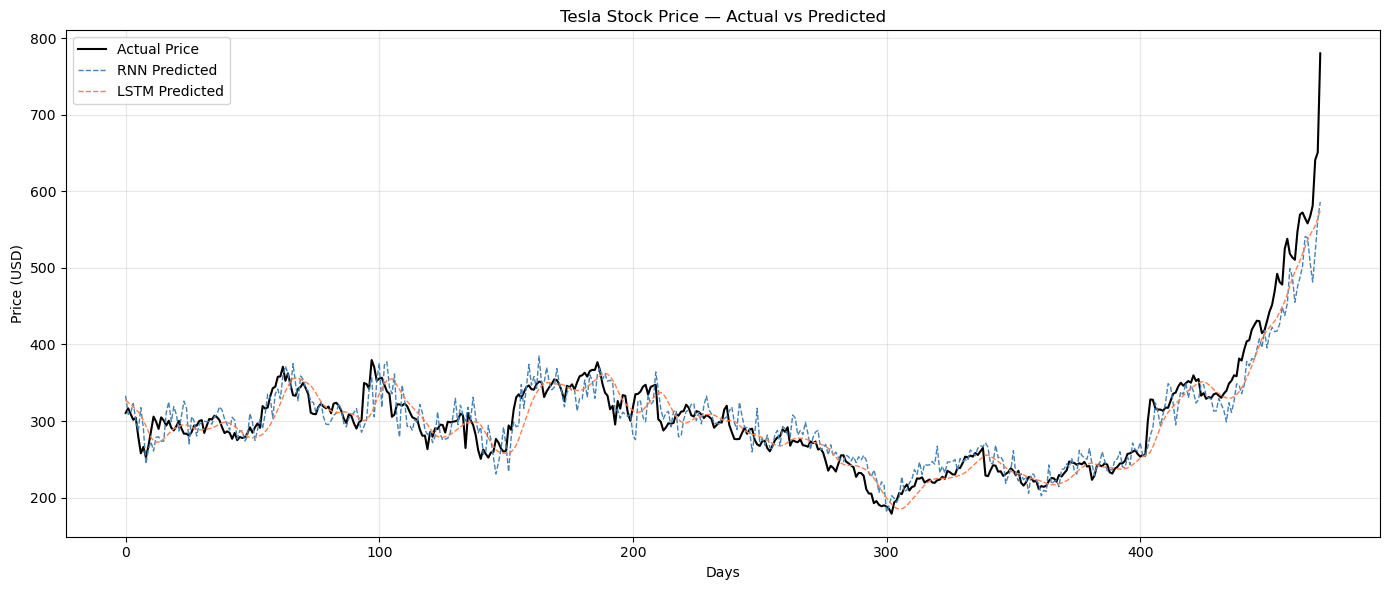

In [23]:
# Actual vs Predicted plot
plt.figure(figsize=(14, 6))

plt.plot(y_test_actual, label='Actual Price', color='black', linewidth=1.5)
plt.plot(rnn_pred_actual, label='RNN Predicted', color='steelblue', linewidth=1, linestyle='--')
plt.plot(lstm_pred_actual, label='LSTM Predicted', color='coral', linewidth=1, linestyle='--')

plt.title('Tesla Stock Price — Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


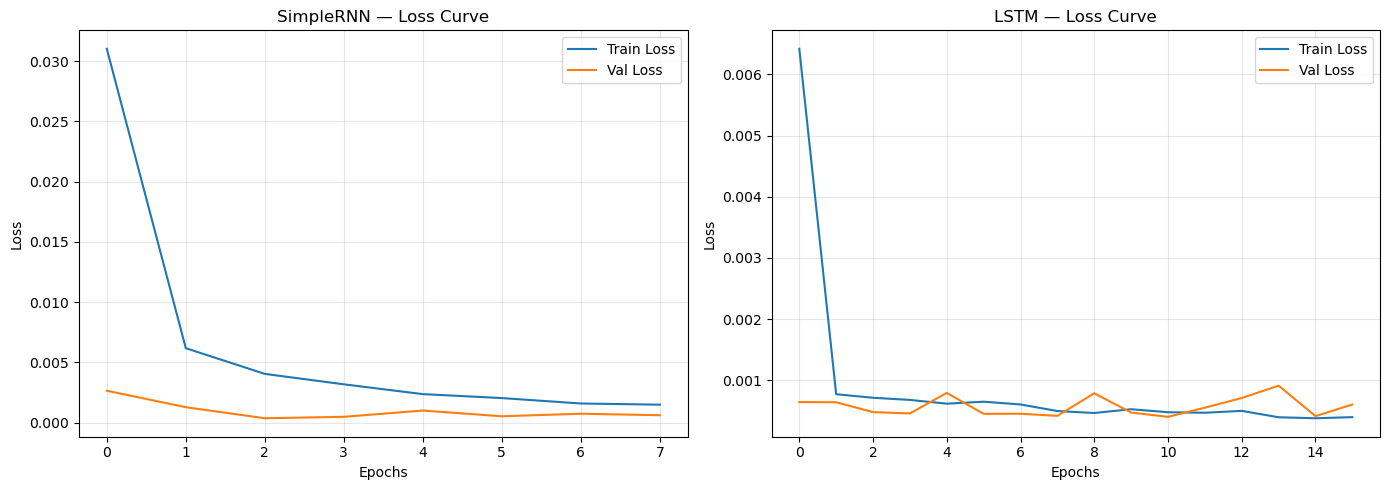

In [24]:
# Loss curve plot

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(rnn_history.history['loss'], label='Train Loss')
plt.plot(rnn_history.history['val_loss'], label='Val Loss')
plt.title('SimpleRNN — Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Val Loss')
plt.title('LSTM — Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# Prediction Function

def predict_future(model, last_sequence, n_days, scaler):
    predictions = []
    current_seq = last_sequence.copy()

    for _ in range(n_days):
        # Reshape to  (1, 60, 1)
        input_seq = current_seq.reshape(1, 60, 1)

        # Predict next day
        next_pred = model.predict(input_seq, verbose=0)[0][0]
        predictions.append(next_pred)

        # Remove oldest day, add new predictions
        current_seq = np.append(current_seq[1:], next_pred)
                               
    # Convert back to actual price
    predictions = np.array(predictions).reshape(-1, 1)
    return scaler.inverse_transform(predictions)
    

In [26]:
# Take last 60 days from scaled data
last_60_days = scaled_data[-60:]

last_price = scaler.inverse_transform([[scaled_data[-1][0]]])[0][0]
print(f"Last actual price: ${last_price:.2f}")

Last actual price: $780.00


In [27]:
# SimpleRNN predictions

rnn_1day  = predict_future(rnn_model, last_60_days, 1,  scaler)
rnn_5day  = predict_future(rnn_model, last_60_days, 5,  scaler)
rnn_10day = predict_future(rnn_model, last_60_days, 10, scaler)

print("=== SimpleRNN Predictions ===")
print(f"1-day  prediction: ${rnn_1day[-1][0]:.2f}")
print(f"5-day  prediction: ${rnn_5day[-1][0]:.2f}")
print(f"10-day prediction: ${rnn_10day[-1][0]:.2f}")

=== SimpleRNN Predictions ===
1-day  prediction: $580.16
5-day  prediction: $566.61
10-day prediction: $488.81


In [28]:
#  LSTM predictions

lstm_1day  = predict_future(lstm_model, last_60_days, 1,  scaler)
lstm_5day  = predict_future(lstm_model, last_60_days, 5,  scaler)
lstm_10day = predict_future(lstm_model, last_60_days, 10, scaler)

print("=== LSTM Predictions ===")
print(f"1-day  prediction: ${lstm_1day[-1][0]:.2f}")
print(f"5-day  prediction: ${lstm_5day[-1][0]:.2f}")
print(f"10-day prediction: ${lstm_10day[-1][0]:.2f}")


=== LSTM Predictions ===
1-day  prediction: $596.29
5-day  prediction: $628.60
10-day prediction: $624.54


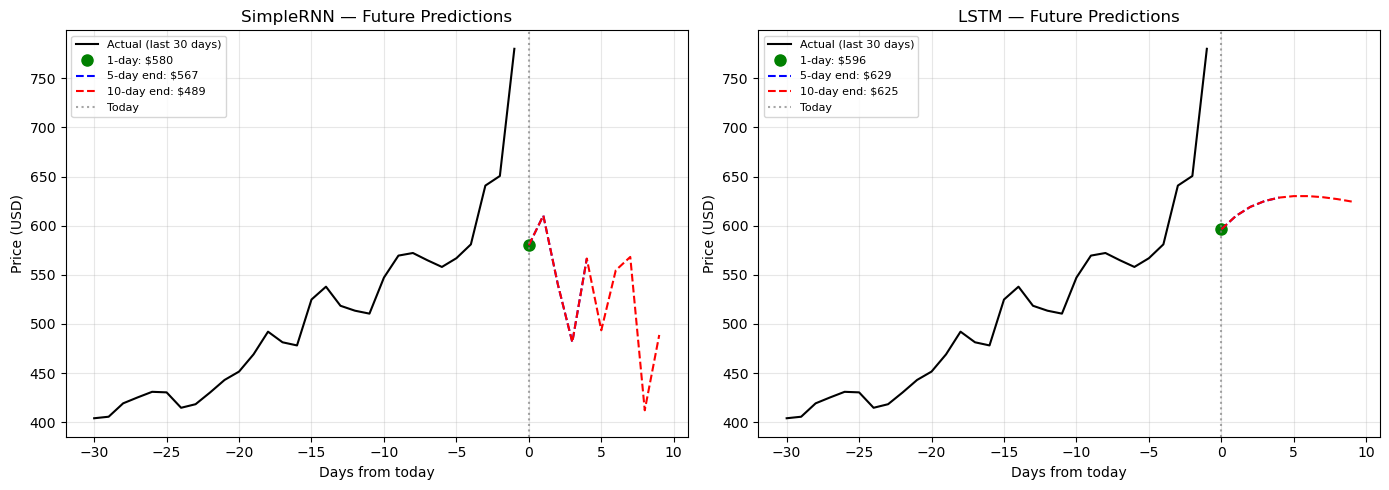

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Last 30 days actual price
last_30_actual = scaler.inverse_transform(scaled_data[-30:])
x_actual = list(range(-30, 0))

for ax, model_name, pred_1, pred_5, pred_10 in zip(
    axes,
    ['SimpleRNN', 'LSTM'],
    [rnn_1day, lstm_1day],
    [rnn_5day, lstm_5day],
    [rnn_10day, lstm_10day]
):
    ax.plot(x_actual, last_30_actual,
            color='black', label='Actual (last 30 days)', linewidth=1.5)

    ax.plot(range(0, 1), [pred_1[-1]],
            'go', markersize=8, label=f'1-day: ${pred_1[-1][0]:.0f}')
    ax.plot(range(0, 5), pred_5,
            'b--', linewidth=1.5, label=f'5-day end: ${pred_5[-1][0]:.0f}')
    ax.plot(range(0, 10), pred_10,
            'r--', linewidth=1.5, label=f'10-day end: ${pred_10[-1][0]:.0f}')

    ax.axvline(x=0, color='gray', linestyle=':', alpha=0.7, label='Today')
    ax.set_title(f'{model_name} — Future Predictions')
    ax.set_xlabel('Days from today')
    ax.set_ylabel('Price (USD)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
#  GridSearchCV

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV



In [31]:
def build_lstm(units=64, dropout_rate =0.2, learning_rate=0.001):
    model= Sequential([
        LSTM(units, return_sequences=True, input_shape=(60,1)),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mean_squared_error'
    )
    return model

In [32]:
# KerasRegressor wrapper
keras_reg = KerasRegressor(
    model=build_lstm,
    epochs=20,
    batch_size=32,
    verbose=0
)

# Parameter grid
param_grid = {
    'model__units':         [32, 64],
    'model__dropout_rate':  [0.1, 0.2],
    'model__learning_rate': [0.001, 0.01]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=keras_reg,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1
)

# Reshape X_train for GridSearch
X_train_2d = X_train.reshape(X_train.shape[0], -1)

print("GridSearchCV starting... This will take 10-15 minutes.")
grid_search.fit(X_train_2d, y_train)

GridSearchCV starting... This will take 10-15 minutes.
Fitting 3 folds for each of 8 candidates, totalling 24 fits


,estimator,KerasRegresso...e epochs=20 )
,param_grid,"{'model__dropout_rate': [0.1, 0.2], 'model__learning_rate': [0.001, 0.01], 'model__units': [32, 64]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,model,<function bui...00170554371C0>


In [34]:
# Best params diye fresh model train koro
import tensorflow as tf
import joblib
tf.keras.backend.clear_session()

final_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(60, 1)),
    Dropout(0.1),
    LSTM(32, return_sequences=False),
    Dropout(0.1),
    Dense(1)
])

final_lstm.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mean_squared_error'
)

callbacks_final = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_lstm_model.keras', save_best_only=True)
]

final_lstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks_final,
    verbose=1
)

# Save koro
final_lstm.save('best_lstm_model.keras')
joblib.dump(scaler, 'scaler.pkl')
np.save('last_60_days.npy', last_60_days)

print("Final model saved!")

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0042 - val_loss: 0.0016
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 3.5603e-04 - val_loss: 3.4022e-04
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.9387e-04 - val_loss: 6.0074e-04
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 2.8630e-04 - val_loss: 2.9155e-04
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 2.4429e-04 - val_loss: 3.0030e-04
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.4058e-04 - val_loss: 2.9137e-04
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 2.3148e-04 - val_loss: 2.7910e-04
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 2.1932e-04 - val_loss: 6.5805e-04
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 2.0961e-04 - val_loss: 2.5552e-04
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 2.3278e-04 - val_loss: 4.9201e-04
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.9189e-04 - val_

In [35]:
# Manual hyperparameter tuning — GridSearchCV er alternative
from itertools import product

param_grid = {
    'units':         [32, 64],
    'dropout_rate':  [0.1, 0.2],
    'learning_rate': [0.001, 0.01]
}

results = []

for units, dropout_rate, learning_rate in product(
    param_grid['units'],
    param_grid['dropout_rate'],
    param_grid['learning_rate']
):
    print(f"Testing: units={units}, dropout={dropout_rate}, lr={learning_rate}")
    
    import tensorflow as tf
    tf.keras.backend.clear_session()
    
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(60, 1)),
        Dropout(dropout_rate),
        LSTM(units // 2, return_sequences=False),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mean_squared_error')
    
    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.1,
        callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
        verbose=0
    )
    
    pred = model.predict(X_test, verbose=0)
    pred_actual = scaler.inverse_transform(pred.reshape(-1, 1))
    mse = mean_squared_error(y_test_actual, pred_actual)
    rmse = np.sqrt(mse)
    
    results.append({
        'units': units,
        'dropout_rate': dropout_rate,
        'learning_rate': learning_rate,
        'rmse': rmse
    })
    print(f"  RMSE: ${rmse:.2f}\n")

# Best result
results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['rmse'].idxmin()]

print("=== BEST PARAMETERS ===")
print(results_df.sort_values('rmse').to_string(index=False))
print(f"\nBest: units={int(best_row['units'])}, "
      f"dropout={best_row['dropout_rate']}, "
      f"lr={best_row['learning_rate']}, "
      f"RMSE=${best_row['rmse']:.2f}")

Testing: units=32, dropout=0.1, lr=0.001
  RMSE: $26.63

Testing: units=32, dropout=0.1, lr=0.01
  RMSE: $18.94

Testing: units=32, dropout=0.2, lr=0.001
  RMSE: $28.19

Testing: units=32, dropout=0.2, lr=0.01
  RMSE: $25.06

Testing: units=64, dropout=0.1, lr=0.001
  RMSE: $20.92

Testing: units=64, dropout=0.1, lr=0.01
  RMSE: $21.01

Testing: units=64, dropout=0.2, lr=0.001
  RMSE: $28.35

Testing: units=64, dropout=0.2, lr=0.01
  RMSE: $21.61

=== BEST PARAMETERS ===
 units  dropout_rate  learning_rate      rmse
    32           0.1          0.010 18.942651
    64           0.1          0.001 20.919067
    64           0.1          0.010 21.009853
    64           0.2          0.010 21.613131
    32           0.2          0.010 25.059738
    32           0.1          0.001 26.634703
    32           0.2          0.001 28.194870
    64           0.2          0.001 28.345727

Best: units=32, dropout=0.1, lr=0.01, RMSE=$18.94


In [36]:
print("=== GRIDSEARCH RESULTS ===")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best MSE Score:  {-grid_search.best_score_:.6f}")

=== GRIDSEARCH RESULTS ===
Best Parameters: {'model__dropout_rate': 0.1, 'model__learning_rate': 0.001, 'model__units': 32}
Best MSE Score:  nan


In [38]:
import joblib

# final_lstm ta already train hoyeche — shetai save koro
rnn_model.save('rnn_model.keras')
final_lstm.save('best_lstm_model.keras')
joblib.dump(scaler, 'scaler.pkl')
np.save('last_60_days.npy', last_60_days)

print("All models saved!")

All models saved!
